In [1]:
# Initializations and Imports
import pandas as pd
import numpy as np

df = pd.read_csv("../data/data_processed.csv")

In [2]:
df.head()

,btb_mean,btb_max,combo_mean,combo_max,immediate_garbage_mean,immediate_garbage_max,incoming_garbage_mean,incoming_garbage_max,won,rating,glicko,glicko_rd,duration_sec,pps,attack_per_piece,apm,tspin_rate
0,1.933673,8,0.520408,7,0.244898,8,0.576531,15,1,24748.521,2701.8877,62.212624,70.600000,2.776204,0.821429,136.827195,0.076531
1,0.413953,4,0.590698,6,0.683721,13,1.432558,13,0,24820.710,2791.8670,63.886936,71.310000,3.015005,0.586047,106.015987,0.055814
2,0.611842,3,0.605263,8,0.250000,6,0.605263,6,1,24820.710,2791.8670,63.886936,49.275000,3.084729,0.671053,124.200913,0.065789
3,0.786765,4,0.588235,6,0.551471,9,1.227941,10,0,24748.521,2701.8877,62.212624,49.283333,2.759554,0.625000,103.483260,0.036765
4,1.277487,7,0.539267,5,0.366492,11,0.691099,11,1,24748.521,2701.8877,62.212624,69.525000,2.747213,0.670157,110.463862,0.057592


In [3]:
df.shape

(70246, 17)

### Train/Validation/Test Split

In [4]:
# 70-15-15 Train-Validation-Test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=['won'])
y = df['won']

# train split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# validation and test split
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

### Feature Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Neural Network Implementation

### Importing and Data Preparation

In [6]:
import matplotlib.pyplot as plt
import itertools
import sys
import os
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import torch
import torch.optim as optim
import torch.nn as nn

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.neural_network import NeuralNetwork
from src.data_loader import DataLoader

%load_ext autoreload
%autoreload 2

torch.manual_seed(0)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1, 1) 

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.to_numpy(), dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)

### Training Flow (One Configuration)

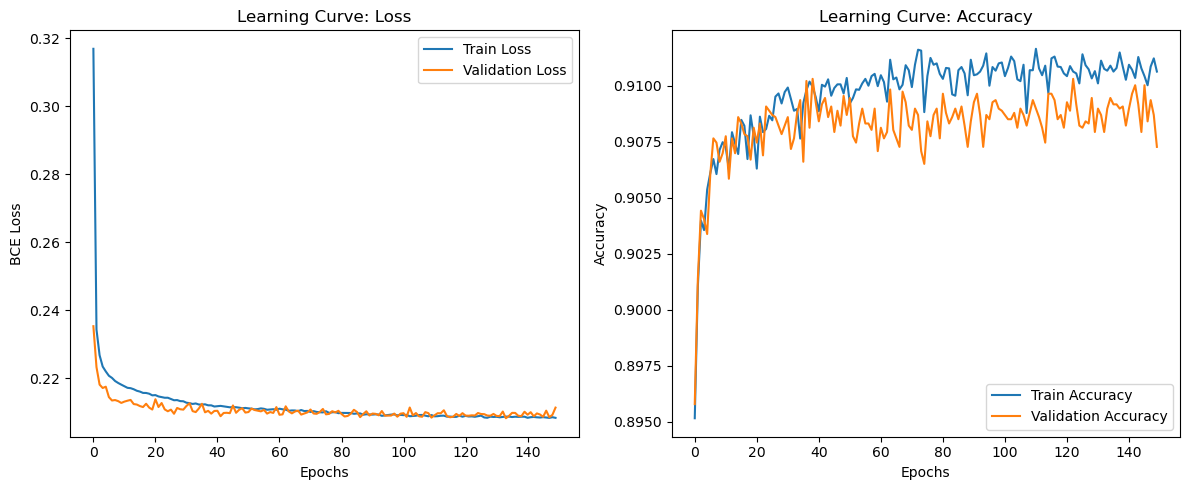

In [ ]:
learning_rate = 0.001
hidden_layers = [16]
batch_size = 32

network = NeuralNetwork(input_size=X_train_t.shape[1], num_classes=1, list_hidden=hidden_layers, activation='relu')
network.create_network()
network.init_weights()

optimizer = optim.Adam(params=network.parameters(), lr=learning_rate)
criterion = nn.BCEWithLogitsLoss()
data_loader = DataLoader(X_train_t.numpy(), y_train_t.numpy(), batch_size=batch_size)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(150):
    network.train()
    X_batch, y_batch = data_loader.get_batch(mode='train')
    
    epoch_train_loss = 0
    for X_b, y_b in zip(X_batch, y_batch):
        X_b = torch.tensor(X_b, dtype=torch.float32)
        y_b = torch.tensor(y_b, dtype=torch.float32)
        
        optimizer.zero_grad()
        scores, _ = network.forward(X_b)
        loss = criterion(scores, y_b)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
        
    avg_train_loss = epoch_train_loss / len(X_batch)
    train_losses.append(avg_train_loss)
    
    network.eval()
    with torch.no_grad():
        t_scores, _ = network.forward(X_train_t)
        t_loss = criterion(t_scores, y_train_t).item()
        t_preds = (torch.sigmoid(t_scores) >= 0.5).float()
        train_accs.append((t_preds == y_train_t).float().mean().item())
        
        v_scores, _ = network.forward(X_val_t)
        v_loss = criterion(v_scores, y_val_t).item()
        val_losses.append(v_loss)
        v_preds = (torch.sigmoid(v_scores) >= 0.5).float()
        val_accs.append((v_preds == y_val_t).float().mean().item())


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Learning Curve: Loss")
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title("Learning Curve: Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Hyperparameter Tuning and Error Analysis

Testing Config - Learning Rate: 0.001, Hidden Layers: [16, 8], Batch Size: 32
Training Accuracy: 0.9127 | Validation Accuracy: 0.9073

Testing Config - Learning Rate: 0.001, Hidden Layers: [16, 8], Batch Size: 64
Training Accuracy: 0.9119 | Validation Accuracy: 0.9060

Testing Config - Learning Rate: 0.001, Hidden Layers: [32, 16], Batch Size: 32
Training Accuracy: 0.9159 | Validation Accuracy: 0.9060

Testing Config - Learning Rate: 0.001, Hidden Layers: [32, 16], Batch Size: 64
Training Accuracy: 0.9150 | Validation Accuracy: 0.9049

Testing Config - Learning Rate: 0.001, Hidden Layers: [8, 4], Batch Size: 32
Training Accuracy: 0.9093 | Validation Accuracy: 0.9066

Testing Config - Learning Rate: 0.001, Hidden Layers: [8, 4], Batch Size: 64
Training Accuracy: 0.9101 | Validation Accuracy: 0.9063

Testing Config - Learning Rate: 0.001, Hidden Layers: [16, 8, 4], Batch Size: 32
Training Accuracy: 0.9127 | Validation Accuracy: 0.9078

Testing Config - Learning Rate: 0.001, Hidden Layers

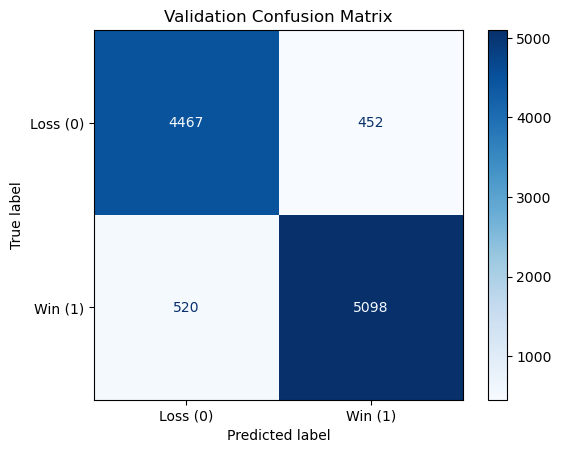

Validation False Positives (Predicted Win, Actually Lost): 452
Validation False Negatives (Predicted Loss, Actually Won): 520


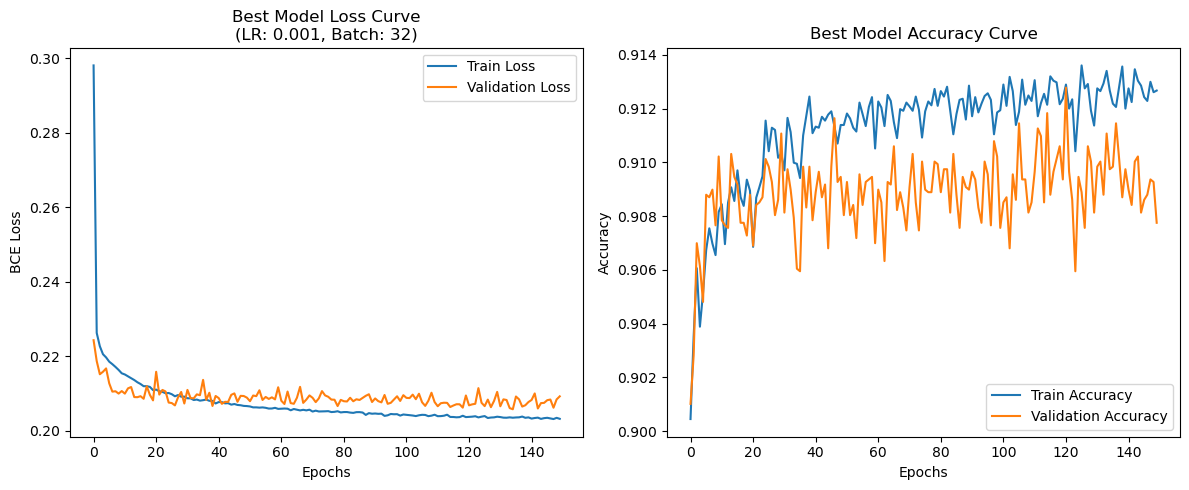

In [8]:
learning_rate = [0.001]
hidden_layers = [
    [16, 8], [32, 16], [8, 4],
    [16, 8, 4], [32, 16, 8], [16, 16, 8],
    [32, 16, 8, 4]
]
batch_sizes = [32, 64]

best_val_accuracy = 0
best_params = {}
best_model_state = None

for lr, h_layers, batch_size in itertools.product(learning_rate, hidden_layers, batch_sizes):
    print(f"Testing Config - Learning Rate: {lr}, Hidden Layers: {h_layers}, Batch Size: {batch_size}")
    network = NeuralNetwork(input_size=X_train_t.shape[1], num_classes=1, list_hidden=h_layers, activation='relu')
    network.create_network()
    network.init_weights()

    optimizer = optim.Adam(params=network.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    data_loader = DataLoader(X_train_t.numpy(), y_train_t.numpy(), batch_size=batch_size)

    temp_train_loss, temp_val_loss = [], []
    temp_train_acc, temp_val_acc = [], []

    for epoch in range(150):
        network.train() 
        X_batch, y_batch = data_loader.get_batch(mode='train')

        epoch_train_loss = 0

        for X_b, y_b in zip(X_batch, y_batch):
            X_b = torch.tensor(X_b, dtype=torch.float32)
            y_b = torch.tensor(y_b, dtype=torch.float32)
            optimizer.zero_grad()
            scores, _ = network.forward(X_b)
            loss = criterion(scores, y_b) 
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
    
        temp_train_loss.append(epoch_train_loss / len(X_batch))

        network.eval() 
        with torch.no_grad():
            train_scores, _ = network.forward(X_train_t)
            train_probs = torch.sigmoid(train_scores)
            train_predictions = (train_probs >= 0.5).float()
            train_correct = (train_predictions == y_train_t).sum().item()
            train_accuracy = train_correct / len(y_train_t)
            temp_train_acc.append(train_accuracy)

            val_scores, _ = network.forward(X_val_t)
            val_probs = torch.sigmoid(val_scores)
            val_predictions = (val_probs >= 0.5).float()
            val_correct = (val_predictions == y_val_t).sum().item()
            val_accuracy = val_correct / len(y_val_t)
            val_loss = criterion(val_scores, y_val_t).item()

            temp_val_loss.append(val_loss)
            temp_val_acc.append(val_accuracy)

    print(f"Training Accuracy: {train_accuracy:.4f} | Validation Accuracy: {val_accuracy:.4f}\n")
    
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_params = {'lr': lr, 'hidden_layers': h_layers, 'batch_size': batch_size}
        best_model_state = network.state_dict()

        best_history = {
            'train_loss': temp_train_loss,
            'val_loss': temp_val_loss,
            'train_acc': temp_train_acc,
            'val_acc': temp_val_acc
        }

print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Best Parameters: {best_params}")

final_network = NeuralNetwork(input_size=X_train_t.shape[1], num_classes=1, list_hidden=best_params['hidden_layers'], activation='relu')
final_network.create_network()
final_network.load_state_dict(best_model_state)
final_network.eval()

with torch.no_grad():
    best_val_scores, _ = final_network.forward(X_val_t)
    best_val_predictions = (torch.sigmoid(best_val_scores) >= 0.5).float()

cm = confusion_matrix(y_val_t.numpy(), best_val_predictions.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Loss (0)", "Win (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Validation Confusion Matrix")
plt.show()

false_positives = cm[0][1]
false_negatives = cm[1][0]
print(f"Validation False Positives (Predicted Win, Actually Lost): {false_positives}")
print(f"Validation False Negatives (Predicted Loss, Actually Won): {false_negatives}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(best_history['train_loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Validation Loss')
plt.title(f"Best Model Loss Curve\n(LR: {best_params['lr']}, Batch: {best_params['batch_size']})")
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history['train_acc'], label='Train Accuracy')
plt.plot(best_history['val_acc'], label='Validation Accuracy')
plt.title("Best Model Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Model Evaluation on Test Set

In [11]:
with torch.no_grad():
    test_scores, _ = final_network.forward(X_test_t)
    test_predictions = (torch.sigmoid(test_scores) >= 0.5).float()

print(classification_report(y_test_t.numpy(), test_predictions.numpy(), target_names=["Loss (0)", "Win (1)"], digits=4))

              precision    recall  f1-score   support

    Loss (0)     0.8925    0.9132    0.9027      4919
     Win (1)     0.9224    0.9037    0.9130      5618

    accuracy                         0.9081     10537
   macro avg     0.9075    0.9084    0.9078     10537
weighted avg     0.9085    0.9081    0.9082     10537

